We are planning on working on a covid patient dataset, with the intent of determining how life threatening their condition is, based on previous medical history. These include age, pregnancy, diabetes, etc., with plans to rank these conditions depending on how likely each condition is to be present with the patients that died. We feel that this is very doable within python as a coding platform using the pandas library, and should require enough work to analyze the dataset and then be able to input information to give prognoses on how life threatening a patient's condition might be.

https://www.kaggle.com/datasets/meirnizri/covid19-dataset

> Add blockquote



In [ ]:
import os

# Install the Kaggle library
!pip install kaggle

# Create a .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the kaggle.json file into the .kaggle directory
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json


mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d meirnizri/covid19-dataset

# Unzip the downloaded file
!unzip covid19-dataset.zip

print("Dataset downloaded and unzipped.")

# List the files to identify the CSV name (it's often similar to the dataset name)
!ls

Dataset URL: https://www.kaggle.com/datasets/meirnizri/covid19-dataset
License(s): CC0-1.0
100% 4.66M/4.66M [00:00<00:00, 72.2MB/s]

Archive:  covid19-dataset.zip
  inflating: Covid Data.csv          
Dataset downloaded and unzipped.
 covid19-dataset.zip  'Covid Data.csv'	 sample_data


In [ ]:
import pandas as pd

csv_file_name = 'Covid Data.csv'

# Creating the DataFrame from the data
df = pd.read_csv(csv_file_name)
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT              1048575 non-null  int64 
 9   DIABETES              1048575 non-null  int64 
 10  COPD                  1048575 non-null  int64 
 11  ASTHMA                1048575 non-null  int64 
 12  INMSUPR               1048575 non-null  int64 
 13  HIPERTENSION          1048575 non-null  int64 
 14  OTHER_DISEASE         1048575 non-null  int64 
 15

In [ ]:
df_filtered = df[df['CLASIFFICATION_FINAL'] <= 3]

# Making Death Binary instead of Date wise
df_filtered['DATE_DIED'] = df_filtered['DATE_DIED'].apply(lambda x: 0 if x == '9999-99-99' else 1)
df_filtered = df_filtered.rename(columns={'DATE_DIED': 'Covid Death'})

# Moving the 'Covid Death' column to the first position
cols = ['Covid Death'] + [col for col in df_filtered.columns if col != 'Covid Death']
df_filtered = df_filtered[cols]

# Dropping the CLASIFFICATION_FINAL column
df_filtered = df_filtered.drop(columns=['CLASIFFICATION_FINAL'])

# Defining results (y) and factors (x)
x = df_filtered.drop(columns=['Covid Death'])
y = df_filtered['Covid Death']

# Basic Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state= 42)

df_filtered.head()
df_filtered.info()

/tmp/ipykernel_8478/1576948814.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['DATE_DIED'] = df_filtered['DATE_DIED'].apply(lambda x: 0 if x == '9999-99-99' else 1)


<class 'pandas.core.frame.DataFrame'>
Index: 391979 entries, 0 to 1047937
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Covid Death     391979 non-null  int64
 1   USMER           391979 non-null  int64
 2   MEDICAL_UNIT    391979 non-null  int64
 3   SEX             391979 non-null  int64
 4   PATIENT_TYPE    391979 non-null  int64
 5   INTUBED         391979 non-null  int64
 6   PNEUMONIA       391979 non-null  int64
 7   AGE             391979 non-null  int64
 8   PREGNANT        391979 non-null  int64
 9   DIABETES        391979 non-null  int64
 10  COPD            391979 non-null  int64
 11  ASTHMA          391979 non-null  int64
 12  INMSUPR         391979 non-null  int64
 13  HIPERTENSION    391979 non-null  int64
 14  OTHER_DISEASE   391979 non-null  int64
 15  CARDIOVASCULAR  391979 non-null  int64
 16  OBESITY         391979 non-null  int64
 17  RENAL_CHRONIC   391979 non-null  int64
 18  TOBACCO 

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Classifier Accuracy: {accuracy:.2%}")
print(dtc.fit)

Decision Tree Classifier Accuracy: 89.86%
<bound method DecisionTreeClassifier.fit of DecisionTreeClassifier(random_state=42)>


In [ ]:
import pandas as pd

def predict_covid_outcome(
    USMER, MEDICAL_UNIT, SEX, PATIENT_TYPE, INTUBED, PNEUMONIA,
    AGE, PREGNANT, DIABETES, COPD, ASTHMA, INMSUPR, HIPERTENSION,
    OTHER_DISEASE, CARDIOVASCULAR, OBESITY, RENAL_CHRONIC, TOBACCO, ICU
):
    input_data = pd.DataFrame([[
        USMER, MEDICAL_UNIT, SEX, PATIENT_TYPE, INTUBED, PNEUMONIA,
        AGE, PREGNANT, DIABETES, COPD, ASTHMA, INMSUPR, HIPERTENSION,
        OTHER_DISEASE, CARDIOVASCULAR, OBESITY, RENAL_CHRONIC, TOBACCO, ICU
    ]], columns=X_train.columns)

    prediction = dtc.predict(input_data)[0]

    if prediction == 1:
        return "The patient is predicted to be at higher risk of Covid-19 death."
    else:
        return "The patient is predicted to be at lower risk of Covid-19 death."


In [ ]:
help_dict = {
    'USMER': 'Indicates whether the patient is from USMER (a specific medical unit) or not. (1: Yes, 2: No)',
    'MEDICAL_UNIT': 'Type of medical unit where the patient was treated (1-13).',
    'SEX': 'Patient sex (1: Female, 2: Male).',
    'PATIENT_TYPE': 'Type of attention the patient received (1: Outpatient, 2: Inpatient).',
    'INTUBED': 'Whether the patient was intubated (1: Yes, 2: No, 97/99: Not applicable/Unknown).',
    'PNEUMONIA': 'Whether the patient developed pneumonia (1: Yes, 2: No, 97/99: Not applicable/Unknown).',
    'AGE': 'Patient age in years.',
    'PREGNANT': 'Whether the patient is pregnant (1: Yes, 2: No, 97/98: Not applicable/Unknown).',
    'DIABETES': 'Whether the patient has diabetes (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).',
    'COPD': 'Whether the patient has Chronic Obstructive Pulmonary Disease (COPD) (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).',
    'ASTHMA': 'Whether the patient has asthma (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).',
    'INMSUPR': 'Whether the patient is immunosuppressed (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).',
    'HIPERTENSION': 'Whether the patient has hypertension (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).',
    'OTHER_DISEASE': 'Whether the patient has other diseases (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).',
    'CARDIOVASCULAR': 'Whether the patient has cardiovascular disease (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).',
    'OBESITY': 'Whether the patient is obese (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).',
    'RENAL_CHRONIC': 'Whether the patient has chronic renal disease (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).',
    'TOBACCO': 'Whether the patient is a tobacco user (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).',
    'ICU': 'Whether the patient was admitted to an Intensive Care Unit (ICU) (1: Yes, 2: No, 97/99: Not applicable/Unknown).'
}

In [ ]:

input_features = {}
feature_columns = list(X_train.columns)
current_feature_index = 0

while current_feature_index < len(feature_columns):
    column = feature_columns[current_feature_index]
    description = help_dict.get(column, f"Enter value for {column}: ")

    if current_feature_index == 0:
        user_input = input(f"Enter value for {column} ({description}) (Type 'b' to go back): ").strip().lower()
    else:
        user_input = input(f"Enter value for {column} ({description}): ").strip().lower()

    if user_input == 'b':
        if current_feature_index > 0:
            # Remove the value for the column that was just prompted (the one before backtracking)
            del input_features[feature_columns[current_feature_index - 1]]
            current_feature_index -= 1
            print(f"Going back to {feature_columns[current_feature_index]} (previous input removed).")
        else:
            print("Already at the first input. Cannot go back.")
        continue # Continue to the next iteration (which will be the previous column)

    try:
        value = int(user_input)
        input_features[column] = value
        current_feature_index += 1
    except ValueError:
        print("Invalid input. Please enter an integer or 'b' to go back.")

# Call the prediction function with the collected inputs
prediction_result = predict_covid_outcome(
    USMER=input_features['USMER'],
    MEDICAL_UNIT=input_features['MEDICAL_UNIT'],
    SEX=input_features['SEX'],
    PATIENT_TYPE=input_features['PATIENT_TYPE'],
    INTUBED=input_features['INTUBED'],
    PNEUMONIA=input_features['PNEUMONIA'],
    AGE=input_features['AGE'],
    PREGNANT=input_features['PREGNANT'],
    DIABETES=input_features['DIABETES'],
    COPD=input_features['COPD'],
    ASTHMA=input_features['ASTHMA'],
    INMSUPR=input_features['INMSUPR'],
    HIPERTENSION=input_features['HIPERTENSION'],
    OTHER_DISEASE=input_features['OTHER_DISEASE'],
    CARDIOVASCULAR=input_features['CARDIOVASCULAR'],
    OBESITY=input_features['OBESITY'],
    RENAL_CHRONIC=input_features['RENAL_CHRONIC'],
    TOBACCO=input_features['TOBACCO'],
    ICU=input_features['ICU']
)

print(f"\nPrediction: {prediction_result}")

Enter value for USMER (Indicates whether the patient is from USMER (a specific medical unit) or not. (1: Yes, 2: No)) (Type 'b' to go back): 1
Enter value for MEDICAL_UNIT (Type of medical unit where the patient was treated (1-13).): 1
Enter value for SEX (Patient sex (1: Female, 2: Male).): 1
Enter value for PATIENT_TYPE (Type of attention the patient received (1: Outpatient, 2: Inpatient).): 1
Enter value for INTUBED (Whether the patient was intubated (1: Yes, 2: No, 97/99: Not applicable/Unknown).): 1
Enter value for PNEUMONIA (Whether the patient developed pneumonia (1: Yes, 2: No, 97/99: Not applicable/Unknown).): 1
Enter value for AGE (Patient age in years.): 1
Enter value for PREGNANT (Whether the patient is pregnant (1: Yes, 2: No, 97/98: Not applicable/Unknown).): 1
Enter value for DIABETES (Whether the patient has diabetes (1: Yes, 2: No, 97/98/99: Not applicable/Unknown).): 1
Enter value for COPD (Whether the patient has Chronic Obstructive Pulmonary Disease (COPD) (1: Yes, 

/tmp/ipykernel_7240/2985426110.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_death_rates = df_filtered.groupby('Age_Group')['Covid Death'].value_counts(normalize=True).unstack()
/tmp/ipykernel_7240/2985426110.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_death_percentage.index, y=age_death_percentage.values, palette='coolwarm')


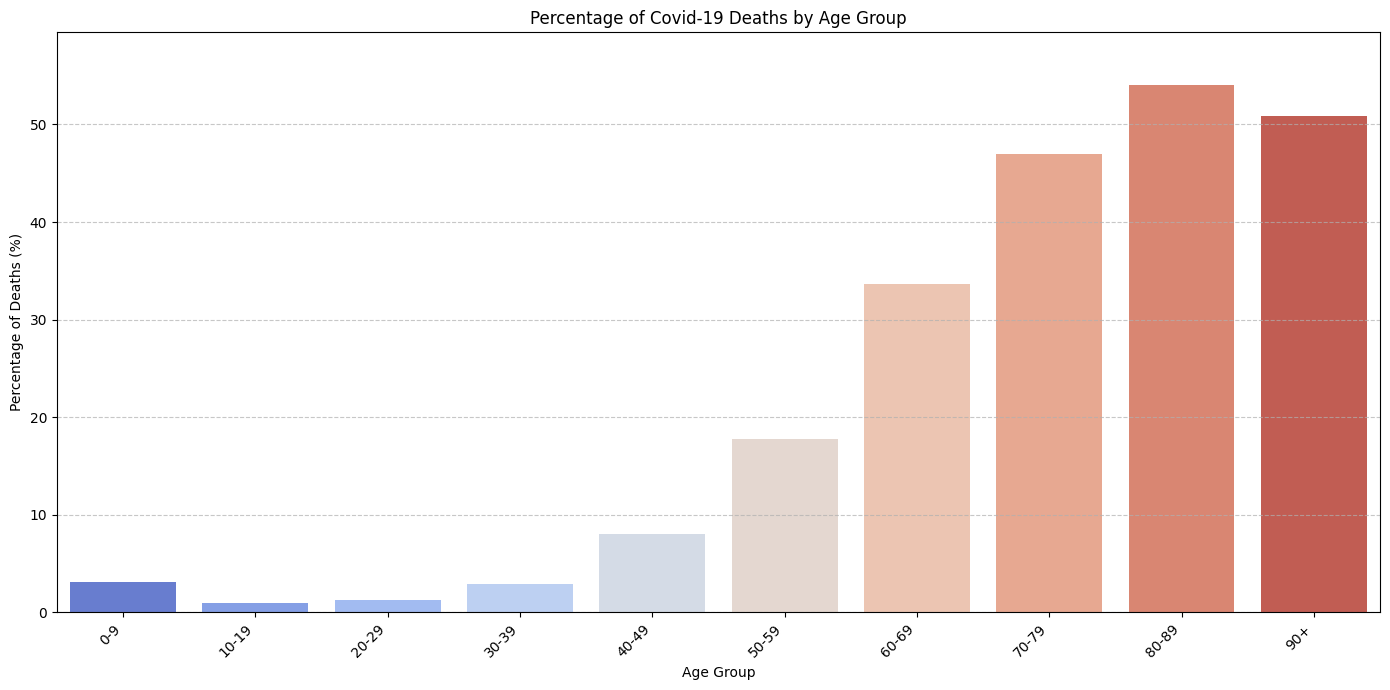

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create age bins. You can adjust the bins as needed.
# For example, 0-9, 10-19, 20-29, ..., 90+
min_age = df_filtered['AGE'].min()
max_age = df_filtered['AGE'].max()

# Define wider bins for better visualization if there's a wide age range
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 120] # Covers up to 120, adjust if max_age is higher
age_labels = [f'{i}-{i+9}' for i in range(0, 90, 10)] + ['90+']

# Ensure bins cover the entire age range in df_filtered
# if max_age > age_bins[-1], extend the last bin or add more
if max_age > age_bins[-1]:
    age_bins.append(max_age + 1) # Ensure the largest age is included
    age_labels.append(f'{age_bins[-2]}+')
    # Re-evaluate labels to ensure correct format if more bins were added dynamically.
    # For simplicity here, we assume the initial age_bins cover most cases,
    # but a more robust solution would dynamically generate labels after bin finalization.
    print(f"Warning: Max age ({max_age}) is beyond initial bins. Adjusted bins: {age_bins}")

df_filtered['Age_Group'] = pd.cut(df_filtered['AGE'], bins=age_bins, labels=age_labels, right=False)

# Calculate death rate per age group
age_death_rates = df_filtered.groupby('Age_Group')['Covid Death'].value_counts(normalize=True).unstack()

# Get the percentage of deaths (where 'Covid Death' == 1)
age_death_percentage = age_death_rates.get(1, pd.Series(0, index=age_death_rates.index)) * 100

# Drop rows where Age_Group might be NaN (if any ages fall outside the defined bins, which should not happen with current bin definition)
age_death_percentage = age_death_percentage.dropna()

# Sort by age group if labels are not naturally sorted after groupby
age_death_percentage = age_death_percentage.reindex(age_labels, fill_value=0)

# Create the bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x=age_death_percentage.index, y=age_death_percentage.values, palette='coolwarm')
plt.title('Percentage of Covid-19 Deaths by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage of Deaths (%)')
plt.ylim(0, age_death_percentage.max() * 1.1) # Set y-limit slightly above max percentage
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1047/3024116087.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=medical_unit_death_percentage.index, y=medical_unit_death_percentage.values, palette='viridis')


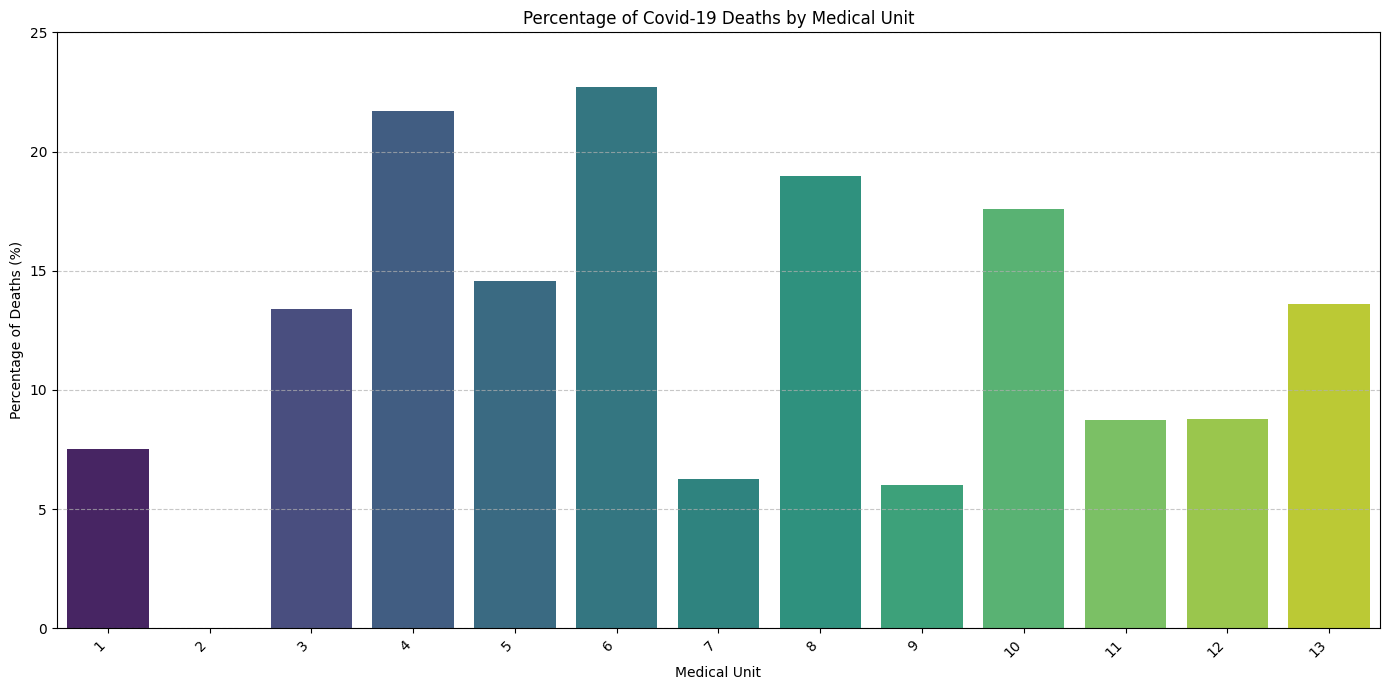

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate death rate per medical unit
medical_unit_death_rates = df_filtered.groupby('MEDICAL_UNIT')['Covid Death'].value_counts(normalize=True).unstack()

# Get the percentage of deaths (where 'Covid Death' == 1)
medical_unit_death_percentage = medical_unit_death_rates.get(1, pd.Series(0, index=medical_unit_death_rates.index)) * 100

# Sort the medical units by death percentage for better visualization
medical_unit_death_percentage = medical_unit_death_percentage.sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x=medical_unit_death_percentage.index, y=medical_unit_death_percentage.values, palette='viridis')
plt.title('Percentage of Covid-19 Deaths by Medical Unit')
plt.xlabel('Medical Unit')
plt.ylabel('Percentage of Deaths (%)')
plt.ylim(0, medical_unit_death_percentage.max() * 1.1) # Set y-limit slightly above max percentage
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7240/3430439001.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=death_percentage_series.values, y=death_percentage_series.index, palette='rocket')


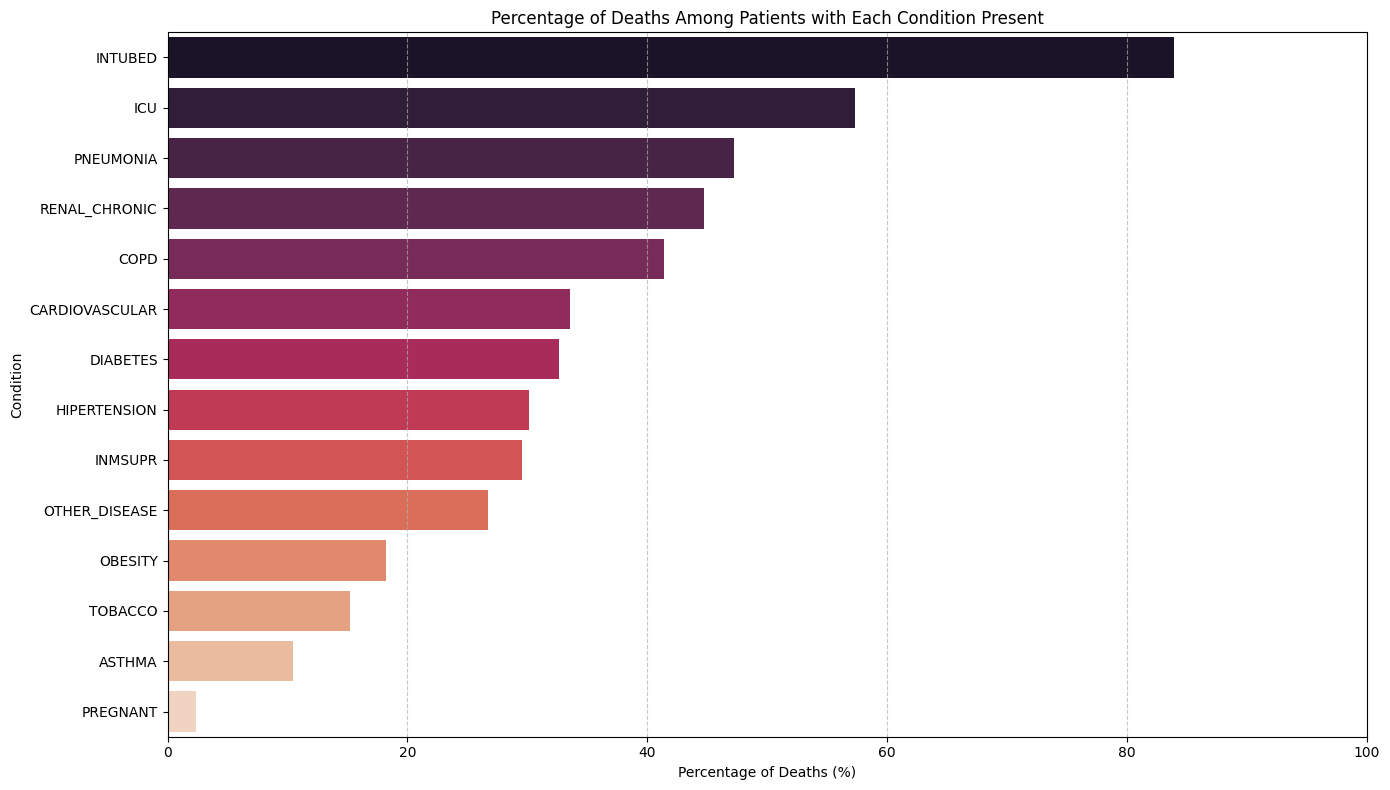

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define binary condition columns where '1' means 'Yes' and '2' means 'No'
binary_condition_cols = [
    'INTUBED', 'PNEUMONIA', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA',
    'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
    'RENAL_CHRONIC', 'TOBACCO', 'ICU'
]

death_percentage_for_yes_cases = {}

for col in binary_condition_cols:
    # Filter for the population where the current condition is 'Yes' (value 1)
    yes_cases_for_condition = df_filtered[df_filtered[col] == 1]

    if not yes_cases_for_condition.empty:
        # Calculate the percentage of deaths within this 'yes' population
        death_count = yes_cases_for_condition['Covid Death'].sum()
        total_yes_cases = yes_cases_for_condition.shape[0]
        percentage = (death_count / total_yes_cases) * 100
        death_percentage_for_yes_cases[col] = percentage
    else:
        death_percentage_for_yes_cases[col] = 0 # No 'yes' cases for this condition

# Convert to a pandas Series for easy plotting and sorting
death_percentage_series = pd.Series(death_percentage_for_yes_cases).sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(14, 8))
sns.barplot(x=death_percentage_series.values, y=death_percentage_series.index, palette='rocket')
plt.title('Percentage of Deaths Among Patients with Each Condition Present')
plt.xlabel('Percentage of Deaths (%)')
plt.ylabel('Condition')
plt.xlim(0, 100) # Ensure x-axis goes from 0 to 100
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8478/3727735316.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=death_percentage_series_no.values, y=death_percentage_series_no.index, palette='rocket')


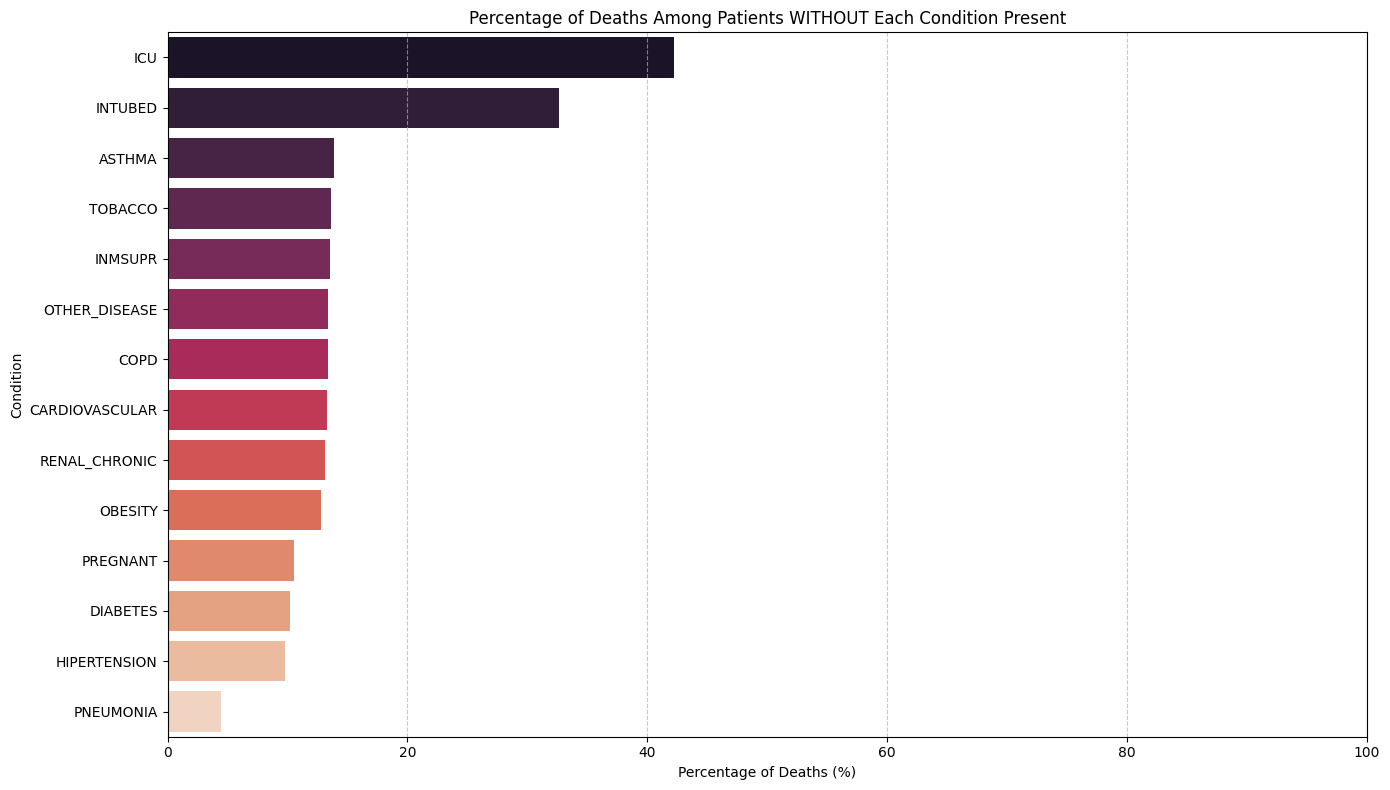

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define binary condition columns where '1' means 'Yes' and '2' means 'No'
binary_condition_cols = [
    'INTUBED', 'PNEUMONIA', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA',
    'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
    'RENAL_CHRONIC', 'TOBACCO', 'ICU'
]

death_percentage_for_no_cases = {}

for col in binary_condition_cols:
    # Filter for the population where the current condition is 'No' (value 2)
    no_cases_for_condition = df_filtered[df_filtered[col] == 2]

    if not no_cases_for_condition.empty:
        # Calculate the percentage of deaths within this 'no' population
        death_count = no_cases_for_condition['Covid Death'].sum()
        total_no_cases = no_cases_for_condition.shape[0]
        percentage = (death_count / total_no_cases) * 100
        death_percentage_for_no_cases[col] = percentage
    else:
        death_percentage_for_no_cases[col] = 0 # No 'no' cases for this condition

# Convert to a pandas Series for easy plotting and sorting
death_percentage_series_no = pd.Series(death_percentage_for_no_cases).sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(14, 8))
sns.barplot(x=death_percentage_series_no.values, y=death_percentage_series_no.index, palette='rocket')
plt.title('Percentage of Deaths Among Patients WITHOUT Each Condition Present')
plt.xlabel('Percentage of Deaths (%)')
plt.ylabel('Condition')
plt.xlim(0, 100) # Ensure x-axis goes from 0 to 100
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
total_deaths = df_dead.shape[0]
print(f"Total death count: {total_deaths}")


Total death count: 54236
